In [20]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/hamnawaseem112222222/sms-spam-collection-5572-labeled-sms-messages/sms_spam_collection (1).csv


# **Table of Contents**
✅ **Import Packages.**   
✅ **Data Import. & EDA.**   
✅ **Data Cleaning.**   
✅ **Data Visualization.**   
✅ **Data Preprocessing.**   
✅ **ML.**   

# **Import Packages.**

In [21]:
#Data Handling & Visualize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import time

from plotly.subplots import make_subplots
import plotly.graph_objects as go

import warnings
warnings.filterwarnings("ignore")

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# **Data Import. & EDA**

In [22]:
df = pd.read_csv('/kaggle/input/datasets/hamnawaseem112222222/sms-spam-collection-5572-labeled-sms-messages/sms_spam_collection (1).csv')

### **Description**
[Link](https://www.kaggle.com/datasets/hamnawaseem112222222/sms-spam-collection-5572-labeled-sms-messages)

In [23]:
# traindata summary 
print(f'{df.info()}')
print('-'* 60)
print(f'df summary \n{df.describe().T}')
print('-'* 60)


#Missing Value & Duplicate Value Check
print(f'Missing Value & Duplicate Value Check')
print(pd.DataFrame(df.isna().sum().reset_index(name='Na')))
print('-'* 60)
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None
------------------------------------------------------------
df summary 
        count unique                     top  freq
label    5572      2                     ham  4825
message  5572   5169  Sorry, I'll call later    30
------------------------------------------------------------
Missing Value & Duplicate Value Check
     index  Na
0    label   0
1  message   0
------------------------------------------------------------
403


In [24]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# **Data Cleaning.**

In [25]:
# Convert labels to numeric
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [26]:
df = df.drop_duplicates()

# **Data Visualization.**

### **CountPlot**

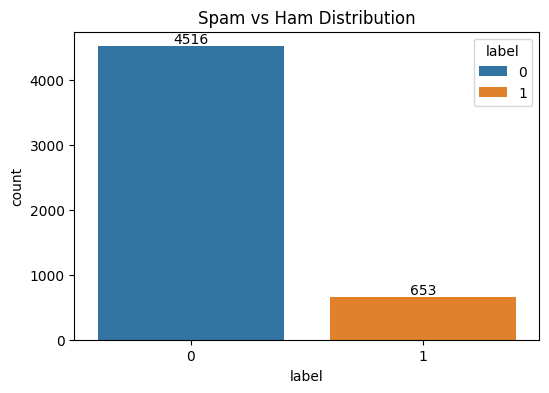

In [27]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='label', hue='label')
for container in ax.containers:
    ax.bar_label(container)

plt.title("Spam vs Ham Distribution")
plt.show()

### **WordCloud**

In [28]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return tokens

In [29]:
spam_text = df[df['label'] == 1]['message']
ham_text = df[df['label'] == 0]['message']

spam_tokens = []
for text in spam_text:
    spam_tokens.extend(preprocess_text(text))

ham_tokens = []
for text in ham_text:
    ham_tokens.extend(preprocess_text(text))

In [30]:
spam_words = ' '.join(spam_tokens)
ham_words = ' '.join(ham_tokens)

spam_wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(spam_words)

ham_wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(ham_words)

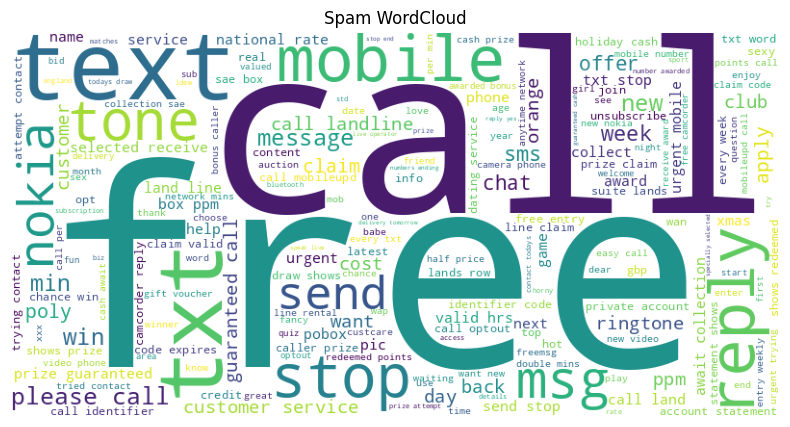

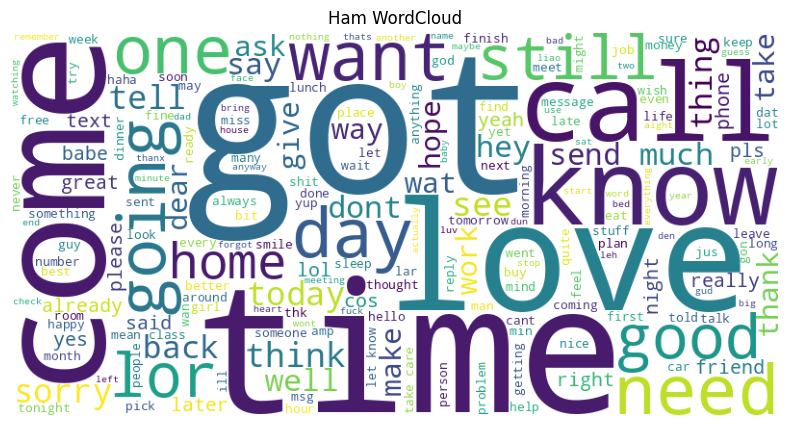

In [31]:
plt.figure(figsize=(10, 5))
plt.imshow(spam_wc)
plt.axis('off')
plt.title('Spam WordCloud')
plt.show()

plt.figure(figsize=(10, 5))
plt.imshow(ham_wc)
plt.axis('off')
plt.title('Ham WordCloud')
plt.show()

**Spam : free, text, txt, call ...**   
**ham : got, time, love, call ...**   

In [32]:
df['text'] = df['message'].apply(preprocess_text)

### **Spam TFIDF**

In [33]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    max_features=3000,
    ngram_range=(1, 2)
)

spam_text_tfidf = tfidf.fit_transform(spam_text)

tfidf_spam_text = pd.DataFrame(
    spam_text_tfidf.toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_mean = tfidf_spam_text.mean().sort_values(ascending=False)

tfidf_mean.head(20)

free       0.030430
text       0.022006
stop       0.020126
txt        0.020112
mobile     0.019699
ur         0.019218
reply      0.019025
claim      0.017774
prize      0.016579
new        0.015455
www        0.014896
just       0.013988
won        0.013813
uk         0.013774
urgent     0.013126
service    0.013104
cash       0.013095
send       0.012667
150p       0.012242
message    0.011948
dtype: float64

# **ML**

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score


In [35]:
X = df['message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
models = {
    'MultinomialNB': MultinomialNB(),
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'LinearSVC': LinearSVC(class_weight='balanced')
}

MultinomialNB accuracy: 0.9749
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       903
           1       1.00      0.80      0.89       131

    accuracy                           0.97      1034
   macro avg       0.99      0.90      0.94      1034
weighted avg       0.98      0.97      0.97      1034



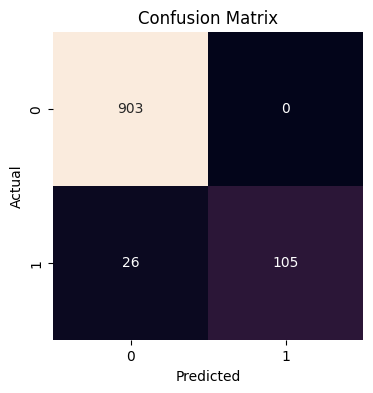

--------------------------------------------------
LogisticRegression accuracy: 0.9739
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       903
           1       0.91      0.89      0.90       131

    accuracy                           0.97      1034
   macro avg       0.94      0.94      0.94      1034
weighted avg       0.97      0.97      0.97      1034



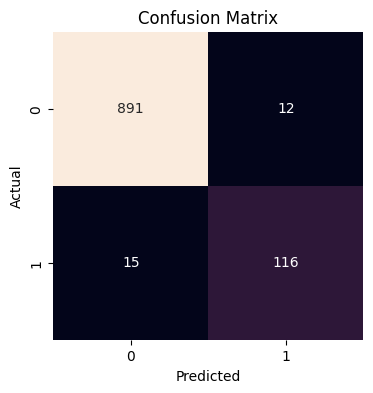

--------------------------------------------------
LinearSVC accuracy: 0.9778
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       903
           1       0.94      0.89      0.91       131

    accuracy                           0.98      1034
   macro avg       0.96      0.94      0.95      1034
weighted avg       0.98      0.98      0.98      1034



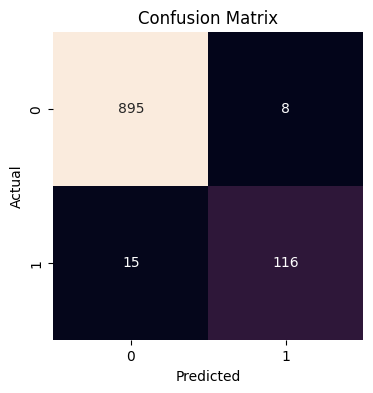

--------------------------------------------------


In [43]:
results = []

for name, clf in models.items():
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(
            lowercase=True,
            stop_words='english',
            ngram_range=(1, 2),
            max_features=3000
        )),
        ('model', clf)
    ])
    
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    
    results.append([name, acc, f1])

    cm = confusion_matrix(y_test, pred)
    print(f'{name} accuracy: {round(acc,4)}')
    print(classification_report(y_test, pred))
 
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cbar=False)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    print("-"*50)
    


#### **Model Comparison**

In [44]:
result_df = pd.DataFrame(results, columns=['model', 'accuracy', 'spam_f1'])
result_df

,model,accuracy,spam_f1
0,MultinomialNB,0.974855,0.889831
1,LogisticRegression,0.973888,0.895753
2,LinearSVC,0.977756,0.909804


### **TEST**

In [50]:
best_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        stop_words='english',
        ngram_range=(1, 2),
        max_features=3000
    )),
    ('model', LinearSVC(class_weight='balanced'))
])

best_model.fit(X_train, y_train)
pred = best_model.predict(X_test)

In [51]:
# Make GPT 

sample_messages = [
    "Congratulations! You won a free ticket. Call now!",
    "Hey, are we still meeting at 7?",
    "URGENT! Your account has won a prize. Claim now.",
    "Can you call me when you get home?"
]

best_model.predict(sample_messages)

array([1, 0, 1, 0])

In [52]:
scores = best_model.decision_function(sample_messages)

pd.DataFrame({
    'message': sample_messages,
    'prediction': best_model.predict(sample_messages),
    'score': scores
})

,message,prediction,score
0,Congratulations! You won a free ticket. Call now!,1,0.476275
1,"Hey, are we still meeting at 7?",0,-1.471883
2,URGENT! Your account has won a prize. Claim now.,1,1.488532
3,Can you call me when you get home?,0,-1.775241


--------------------
**Thankyou, Please leave your advice in the comments**